## generate QA and graphs

Load data

In [1]:
import json
import pandas as pd

with open('processed_data/dedup_food_based_pairs.json') as f:
    food_based_pairs = json.load(f)

food_info = pd.read_csv('../task_2_foods_filtering_qa_creation/processed_data/reduced_mixed_dishes_v4.csv')
user_info = pd.read_csv('../processed_data/user_tagging.csv').drop_duplicates()
fndds_food = pd.read_csv('../data/fndds_ingredients.csv')
user_habits = pd.read_csv('../processed_data/trimmedHabit.csv')

Generate questions by LLMs, generate answers based on rules, integrate user habits and food ingredients when constructing graphs

In [4]:
def generate_answer(food_tag, user):
    reasons_for_yes = []
    reasons_for_no = []
    used_nutrition_tags = []
    for nutrition in list(user.keys())[1:]:
        if nutrition in list(food_tag.keys()):
            level = 'high' if food_tag[nutrition] == 1 else 'low'
            used_nutrition_tags.append(level + '_' + nutrition)
            if user[nutrition] == food_tag[nutrition]:
                reasons_for_yes.append(str(level) + ' in ' + str(nutrition))
            else:
                reasons_for_no.append(str(level) + ' in ' + str(nutrition))
    if reasons_for_no != []:
        answer = 'No, because the food is '
        for reason in reasons_for_no:
            answer += reason + ', '
        answer = answer[:-2] + '. '
    else:
        answer = 'Yes, because the food is '
        for reason in reasons_for_yes:
            answer += reason + ', '
        answer = answer[:-2] + '. '
    
    answer1 = 'Yes.' if 'Yes' in answer else 'No.'
    answer2 = ', '.join(used_nutrition_tags)
    return [answer1, answer2, answer]


def generate_graph(food_id, user_id):
    node_list = []  # [[node_id: int, node_attr: dict], ...]
    edge_list = []  # [[node_id: int, relation: str, node_id: int], ...]

    node_id = 2  # 0 is the user and 1 is the food

    # related to the food
    food = food_info[food_info['food_id'] == food_id]
    node_list.append([1, {'name': food['food_desc'].item(), 'attr': food_id}])
    # add category and ingredients
    fndds_ingredients = fndds_food[fndds_food['Food code'] == food_id]
    food_category = food['WWEIA_desc'].iloc[0]
    node_list.append([node_id, {'name': 'category', 'attr': food_category}])
    edge_list.append([1, 'belongs to', node_id])
    node_id += 1
    fndds_ingredients = fndds_ingredients['Ingredient description'].tolist()
    for ingredient in fndds_ingredients:
        node_list.append([node_id, {'name': 'ingredient', 'attr': ingredient}])
        edge_list.append([1, 'has', node_id])
        node_id += 1
    # nutrition tag
    primary_nutrition_tags = [
        'low_carb', 'high_carb',
        'low_sugar', 'high_sugar',
        'low_sodium', 'high_sodium',
        'low_calorie', 'high_calorie',
        'low_protein', 'high_protein',
        'low_cholesterol', 'high_cholesterol',
        'low_saturated_fat', 'high_saturated_fat',
    ]
    for column in primary_nutrition_tags:
        if food[column].item() == 1:
            node_list.append([node_id, {'name': 'food_nutrition_tag', 'attr': column}])
            edge_list.append([1, 'contains', node_id])
            node_id += 1
    
    # related to the user
    node_list.append([0, {'name': 'user', 'attr': user_id}])
    habit_list = user_habits[user_habits['SEQN'] == user_id]['habitDesc'].tolist()
    for habit in habit_list:
        node_list.append([node_id, {'name': 'dietary habit', 'attr': habit}])
        edge_list.append([0, 'has', node_id])
        node_id += 1
    user = user_info[user_info['SEQN'] == user_id]
    # print(user.to_dict())
    reference_dict = {'obesity': ['low_calorie'], 
                      'opioid_misuse': ['high_protein', 'low_sugar'],  # add low_sodium in user_tagging
                      'hypertension': ['low_sodium'], 
                      'diabetes': ['low_sugar'],  #  add low_carb when generating user_tagging
                      'Weight loss/Low calorie diet': ['low_calorie'], 
                      'Low fat/Low cholesterol diet': ['low_cholesterol', 'low_saturated_fat'], 
                      'Low salt/Low sodium diet': ['low_sodium'], 
                      'Sugar free/Low sugar diet': ['low_sugar'], 
                      'Diabetic diet': ['low_sugar'],  #  add low_carb when generating user_tagging
                      'Weight gain/Muscle building diet': ['high_calorie', 'high_protein'], 
                      'Low carbohydrate diet': ['low_carb'], 
                      'High protein diet': ['high_protein'], 
                      'Renal/Kidney diet': ['low_protein']}
    for column in reference_dict.keys():
        if user[column].item() == 1:
            status_node_id = node_id
            node_list.append([node_id, {'name': 'status', 'attr': column}])
            edge_list.append([0, 'has', node_id])
            node_id += 1
            # nutrition tag
            is_found = False
            for nutrition_tag in reference_dict[column]:
                level = nutrition_tag.split('_')[0]
                nutrition = nutrition_tag.split('_')[1]
                for node in node_list:
                    if node[1]['name'] == 'food_nutrition_tag':
                        if nutrition in node[1]['attr']:
                            if level in node[1]['attr']:
                                edge_list.append([status_node_id, 'match', node[0]])
                            else:
                                edge_list.append([status_node_id, 'contradict', node[0]])
                            is_found = True
                            break
                if is_found:
                    continue
                node_list.append([node_id, {'name': 'user_nutrition_tag', 'attr': nutrition_tag}])
                edge_list.append([status_node_id, 'need', node_id])
                node_id += 1
                
    # print(node_list)
    # print(edge_list)

    return node_list, edge_list


KGQA_benchmark = [['difficulty', 'question1', 'answer1', 'question2', 'answer2', 'question3', 'answer3', 'node_list', 'edge_list']]
for food_user_pairs in food_based_pairs:
    food_id = food_user_pairs['food_id']
    food_tag = food_user_pairs['food_tag']

    keywords = ['easy', 'medium', 'hard']
    for keyword in keywords:
        for user in food_user_pairs[keyword]:
            user_id = user['user_id']

            # generate question and answer
            question1 = 'If the food {} is a healthy option to the user {}? Please answer with yes or no.'.format(food_id, user_id)
            question2 = 'What nutrition tags are used when considering food {} for user {}?'.format(food_id, user_id)
            question = 'If the food {} is a healthy option to the user {}?'.format(food_id, user_id)
            [answer1, answer2, answer] = generate_answer(food_tag, user)
            
            # genearte graph
            node_list, edge_list = generate_graph(food_id, user_id)
            # graph_viz(node_list, edge_list)

            # print('user tag:', user)
            # print('food tag:', food_user_pairs['food_tag'])
            # print('Question:', question)
            # print('Answer:', answer)
            # print('')
            KGQA_benchmark.append([keyword, question1, answer1, question2, answer2, question, answer, node_list, edge_list])

df = pd.DataFrame(KGQA_benchmark[1:], columns=KGQA_benchmark[0])
df.to_csv('./processed_data/KGQA_benchmark.csv', index=False)
df.head()


,difficulty,question1,answer1,question2,answer2,question3,answer3,node_list,edge_list
0,easy,If the food 58137300 is a healthy option to th...,Yes.,What nutrition tags are used when considering ...,low_sugar,If the food 58137300 is a healthy option to th...,"Yes, because the food is low in sugar.","[[1, {'name': 'Adobo, with noodles', 'attr': 5...","[[1, belongs to, 2], [1, has, 3], [1, has, 4],..."
1,easy,If the food 58137300 is a healthy option to th...,Yes.,What nutrition tags are used when considering ...,low_sugar,If the food 58137300 is a healthy option to th...,"Yes, because the food is low in sugar.","[[1, {'name': 'Adobo, with noodles', 'attr': 5...","[[1, belongs to, 2], [1, has, 3], [1, has, 4],..."
2,easy,If the food 58137300 is a healthy option to th...,Yes.,What nutrition tags are used when considering ...,high_protein,If the food 58137300 is a healthy option to th...,"Yes, because the food is high in protein.","[[1, {'name': 'Adobo, with noodles', 'attr': 5...","[[1, belongs to, 2], [1, has, 3], [1, has, 4],..."
3,easy,If the food 58137300 is a healthy option to th...,Yes.,What nutrition tags are used when considering ...,low_carb,If the food 58137300 is a healthy option to th...,"Yes, because the food is low in carb.","[[1, {'name': 'Adobo, with noodles', 'attr': 5...","[[1, belongs to, 2], [1, has, 3], [1, has, 4],..."
4,easy,If the food 58137300 is a healthy option to th...,Yes.,What nutrition tags are used when considering ...,low_sugar,If the food 58137300 is a healthy option to th...,"Yes, because the food is low in sugar.","[[1, {'name': 'Adobo, with noodles', 'attr': 5...","[[1, belongs to, 2], [1, has, 3], [1, has, 4],..."


Visualize the graph

[[1, {'name': 'Seafood salad', 'attr': 27450080}], [2, {'name': 'category', 'attr': 'Seafood mixed dishes'}], [3, {'name': 'ingredient', 'attr': 'Salt, table, iodized'}], [4, {'name': 'ingredient', 'attr': 'Lemon juice, raw'}], [5, {'name': 'ingredient', 'attr': 'Celery, raw'}], [6, {'name': 'ingredient', 'attr': 'Salad dressing, mayonnaise, regular'}], [7, {'name': 'ingredient', 'attr': 'Crustaceans, lobster, northern, cooked, moist heat'}], [8, {'name': 'ingredient', 'attr': 'Crustaceans, crab, blue, canned'}], [9, {'name': 'ingredient', 'attr': 'Crustaceans, shrimp, mixed species, canned'}], [10, {'name': 'food_nutrition_tag', 'attr': 'low_carb'}], [11, {'name': 'food_nutrition_tag', 'attr': 'low_sugar'}], [12, {'name': 'food_nutrition_tag', 'attr': 'high_sodium'}], [13, {'name': 'food_nutrition_tag', 'attr': 'high_cholesterol'}], [0, {'name': 'user', 'attr': 88054}], [14, {'name': 'dietary habit', 'attr': 'Drinks lots of milk'}], [15, {'name': 'dietary habit', 'attr': 'Eats little 

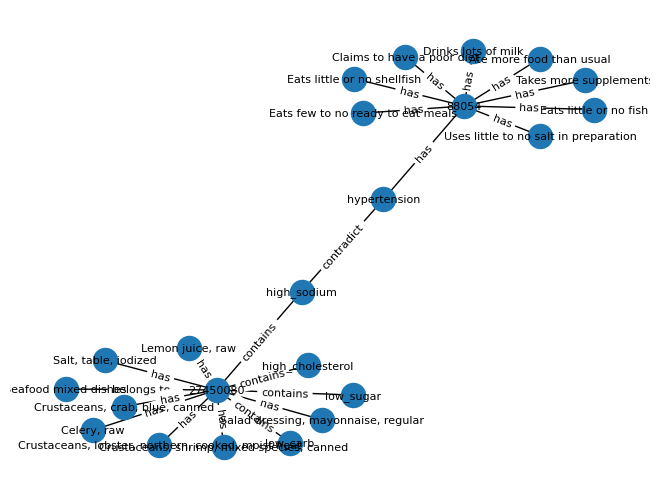

difficulty: easy
question1: If the food 27450080 is a healthy option to the user 88054? Please answer with yes or no.
answer1: No.
question2: What nutrition tags are used when considering food 27450080 for user 88054?
answer2: high_sodium
question3: If the food 27450080 is a healthy option to the user 88054?
answer3: No, because the food is high in sodium. 
node_list: [[1, {'name': 'Seafood salad', 'attr': 27450080}], [2, {'name': 'category', 'attr': 'Seafood mixed dishes'}], [3, {'name': 'ingredient', 'attr': 'Salt, table, iodized'}], [4, {'name': 'ingredient', 'attr': 'Lemon juice, raw'}], [5, {'name': 'ingredient', 'attr': 'Celery, raw'}], [6, {'name': 'ingredient', 'attr': 'Salad dressing, mayonnaise, regular'}], [7, {'name': 'ingredient', 'attr': 'Crustaceans, lobster, northern, cooked, moist heat'}], [8, {'name': 'ingredient', 'attr': 'Crustaceans, crab, blue, canned'}], [9, {'name': 'ingredient', 'attr': 'Crustaceans, shrimp, mixed species, canned'}], [10, {'name': 'food_nutriti

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import ast

def graph_viz(node_list, edge_list):
    G = nx.Graph()
    G.add_nodes_from([(node) for node in node_list])
    G.add_edges_from((edge[0], edge[2], {'relationship': edge[1]}) for edge in edge_list)

    node_labels = {node: data['attr'] for node, data in G.nodes(data=True)}
    edge_labels = nx.get_edge_attributes(G, 'relationship')

    pos = nx.spring_layout(G)
    nx.draw(G, pos)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_color="black")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.5)
    plt.show()

df = pd.read_csv('./processed_data/KGQA_benchmark.csv')
# print(df)
# change the random_state(random seed) to see different samples
random_pair = df.sample(n=1, random_state=1)
node_list = ast.literal_eval(random_pair['node_list'].item())
edge_list = ast.literal_eval(random_pair['edge_list'].item())
print(node_list)
print(edge_list)
graph_viz(node_list, edge_list)

for column, value in random_pair.iloc[0].items():
    print(f"{column}: {value}")